In [50]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [51]:
df=df[(df['job_country']=='United States') & (df['job_title_short']=='Data Analyst')]

In [52]:
df=df.explode('job_skills')

In [56]:
df_us=df.groupby('job_skills')['salary_year_avg'].agg(['size','median'])

In [58]:
df_us=df_us.reset_index()

In [60]:
df_us=df_us.dropna(subset='median')

In [84]:
df_us_1=df_us.sort_values('median',ascending=False).head(10)
df_us_2=df_us.sort_values('size',ascending=False).head(10)

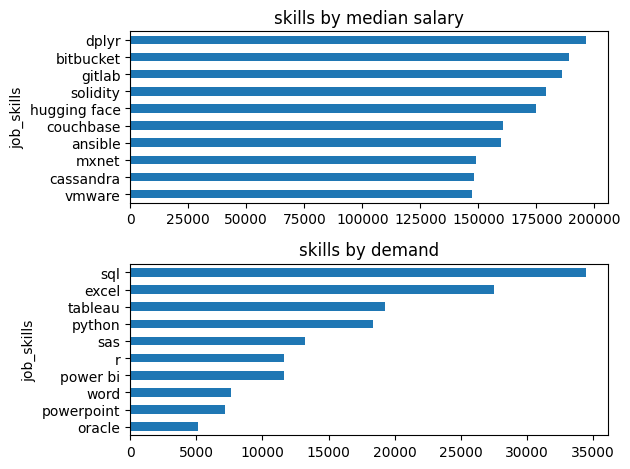

In [89]:
fig,ax=plt.subplots(2,1)

df_us_1.plot(kind='barh',y='median',x='job_skills',ax=ax[0],legend=False,title='skills by median salary')

ax[0].invert_yaxis()
df_us_2.plot(kind='barh',y='size',x='job_skills',ax=ax[1],legend=False,title='skills by demand')
plt.gca().invert_yaxis()
plt.tight_layout()

